In [1]:
#future monthly sales revenue

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
orders=pd.read_csv(r'C:\Users\91930\Downloads\datas\olive ecommerce dataset\olist_orders_dataset.csv')

In [4]:
payments=pd.read_csv(r'C:\Users\91930\Downloads\datas\olive ecommerce dataset\olist_order_payments_dataset.csv')

In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_date           99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [10]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_date                0
dtype: int64

In [11]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [13]:
orders.duplicated().sum()

np.int64(0)

In [14]:
payments.duplicated().sum()

np.int64(0)

In [17]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    dayfirst=True
)

In [18]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_date           99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [19]:
df=orders.merge(payments,on="order_id",how="inner")

In [20]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018,1,credit_card,3,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:00,09-03-2017 09:54,10-03-2017 11:18,17-03-2017 15:08,28-03-2017,1,credit_card,3,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:00,06-02-2018 13:10,07-02-2018 23:22,28-02-2018 17:37,02-03-2018,1,credit_card,3,195.00
103883,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:00,27-08-2017 15:04,28-08-2017 20:52,21-09-2017 11:24,27-09-2017,1,credit_card,5,271.01
103884,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:00,08-01-2018 21:36,12-01-2018 15:35,25-01-2018 23:32,15-02-2018,1,credit_card,4,441.16


In [21]:
df=df[["order_purchase_timestamp","payment_value"]]

In [22]:
df

,order_purchase_timestamp,payment_value
0,2017-10-02 10:56:00,18.12
1,2017-10-02 10:56:00,2.00
2,2017-10-02 10:56:00,18.59
3,2018-07-24 20:41:00,141.46
4,2018-08-08 08:38:00,179.12
...,...,...
103881,2017-03-09 09:54:00,85.08
103882,2018-02-06 12:58:00,195.00
103883,2017-08-27 14:46:00,271.01
103884,2018-01-08 21:28:00,441.16


In [23]:
df["YearMonth"] = df["order_purchase_timestamp"].dt.to_period("M")

C:\Users\91930\AppData\Local\Temp\ipykernel_15700\1890099943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["YearMonth"] = df["order_purchase_timestamp"].dt.to_period("M")


In [24]:
df

,order_purchase_timestamp,payment_value,YearMonth
0,2017-10-02 10:56:00,18.12,2017-10
1,2017-10-02 10:56:00,2.00,2017-10
2,2017-10-02 10:56:00,18.59,2017-10
3,2018-07-24 20:41:00,141.46,2018-07
4,2018-08-08 08:38:00,179.12,2018-08
...,...,...,...
103881,2017-03-09 09:54:00,85.08,2017-03
103882,2018-02-06 12:58:00,195.00,2018-02
103883,2017-08-27 14:46:00,271.01,2017-08
103884,2018-01-08 21:28:00,441.16,2018-01


In [25]:
monthly_revenue = (
    df.groupby("YearMonth")["payment_value"]
      .sum()
      .reset_index()
)

In [27]:
monthly_revenue

,YearMonth,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


In [28]:
monthly_revenue["YearMonth"]=monthly_revenue["YearMonth"].dt.to_timestamp()

In [33]:
monthly_revenue

,YearMonth,payment_value
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01
5,2017-03-01,449863.60
6,2017-04-01,417788.03
7,2017-05-01,592918.82
8,2017-06-01,511276.38
9,2017-07-01,592382.92


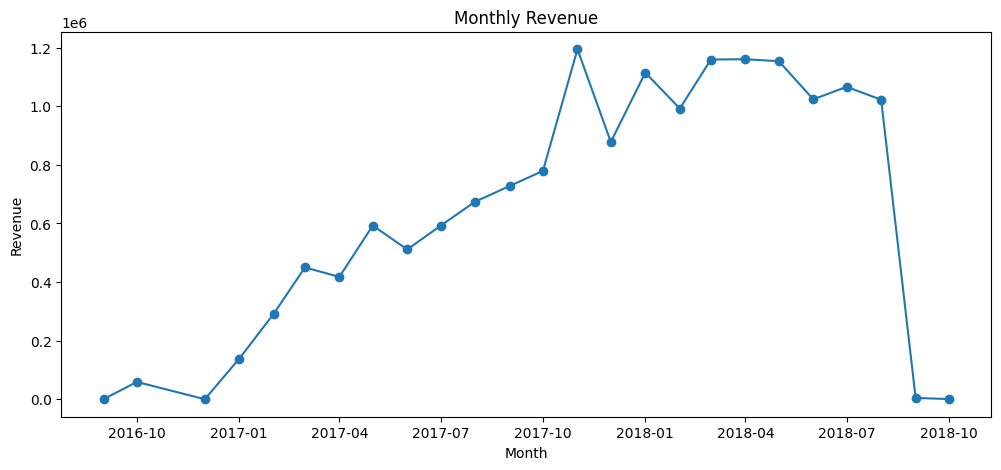

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["payment_value"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

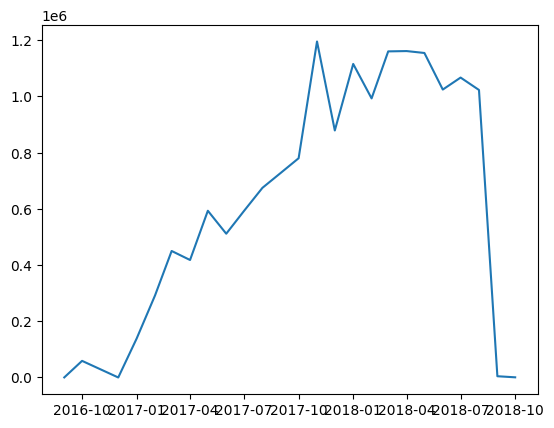

In [34]:
plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["payment_value"])

In [35]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 11.3 MB/s eta 0:00:01
   -------------- ------------------------- 4.5/12.1 MB 11.7 MB/s eta 0:00:01
   ----------------------- ---------------- 7.1/12.1 MB 11.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 11.8 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 11.3 MB/s  0:00:01
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.4 MB/s  0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ----------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
forecast_data = monthly_revenue.rename(
    columns={
        "YearMonth": "ds",
        "payment_value": "y"
    }
)

forecast_data.head()

,ds,y
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01


In [43]:
from prophet import Prophet
model=Prophet()
model.fit(forecast_data)

19:53:33 - cmdstanpy - INFO - Chain [1] start processing
19:53:33 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
future = model.make_future_dataframe(periods=6, freq="M")

C:\Users\91930\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [45]:
forecast=model.predict(future)

C:\Users\91930\AppData\Local\Temp\ipykernel_15700\949325447.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


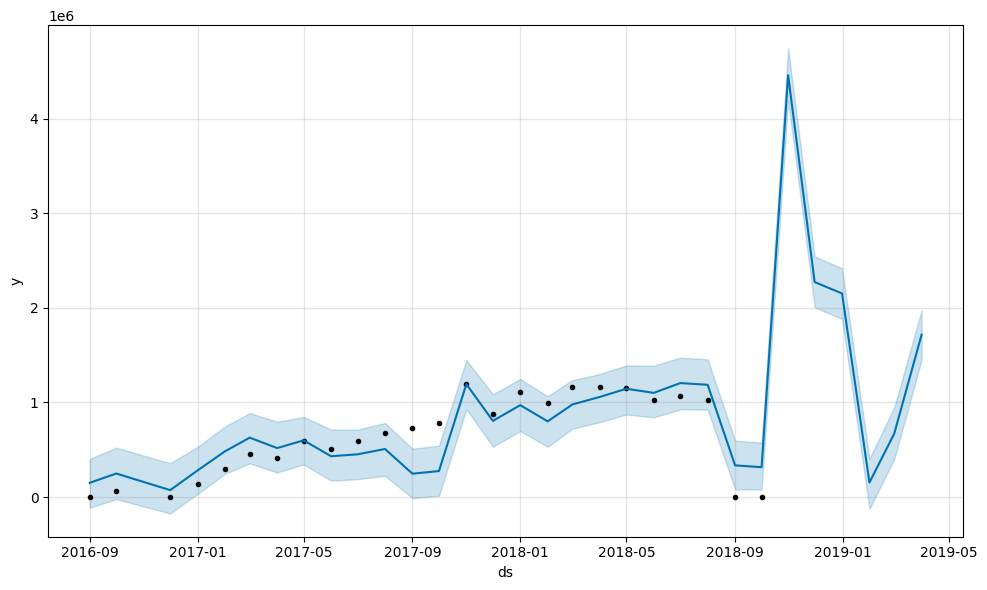

In [48]:
fig=model.plot(forecast)
fig.show()

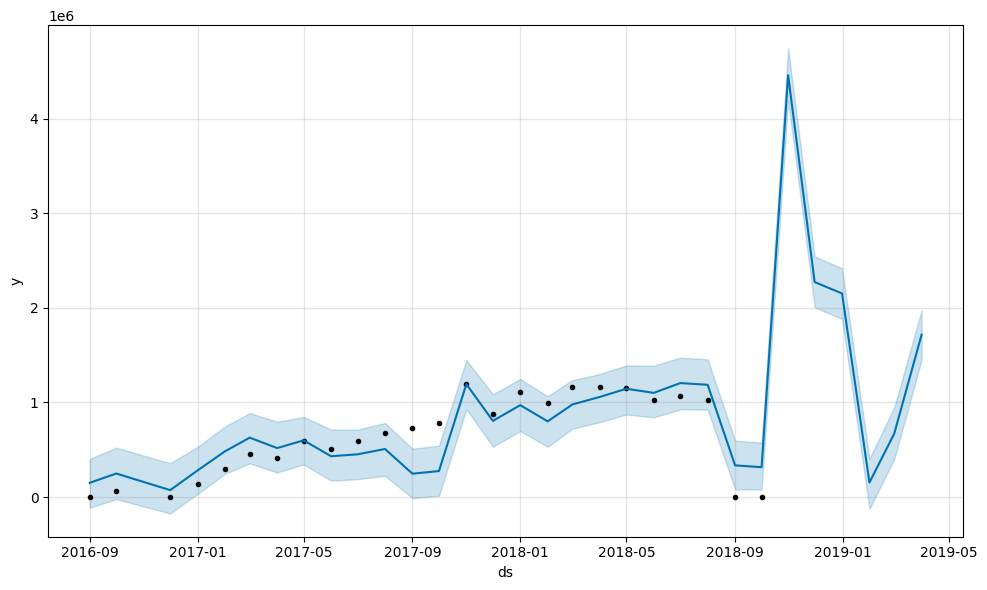

In [49]:
fig = model.plot(forecast)

In [50]:
forecast_result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecast_result.tail(10)

,ds,yhat,yhat_lower,yhat_upper
21,2018-07-01,1.205564e+06,9.274553e+05,1.474533e+06
22,2018-08-01,1.187503e+06,9.250303e+05,1.456334e+06
23,2018-09-01,3.347894e+05,8.120312e+04,5.964177e+05
24,2018-10-01,3.154342e+05,7.926112e+04,5.756746e+05
25,2018-10-31,4.463681e+06,4.193981e+06,4.746525e+06
26,2018-11-30,2.274355e+06,2.006868e+06,2.544826e+06
27,2018-12-31,2.153718e+06,1.883834e+06,2.420641e+06
28,2019-01-31,1.532395e+05,-1.256575e+05,4.069021e+05
29,2019-02-28,6.697176e+05,3.997865e+05,9.492150e+05
30,2019-03-31,1.717843e+06,1.453841e+06,1.975263e+06


In [51]:
forecast_result.to_csv("monthly_revenue_forecast.csv", index=False)

In [52]:
#Visualize Forecast Components

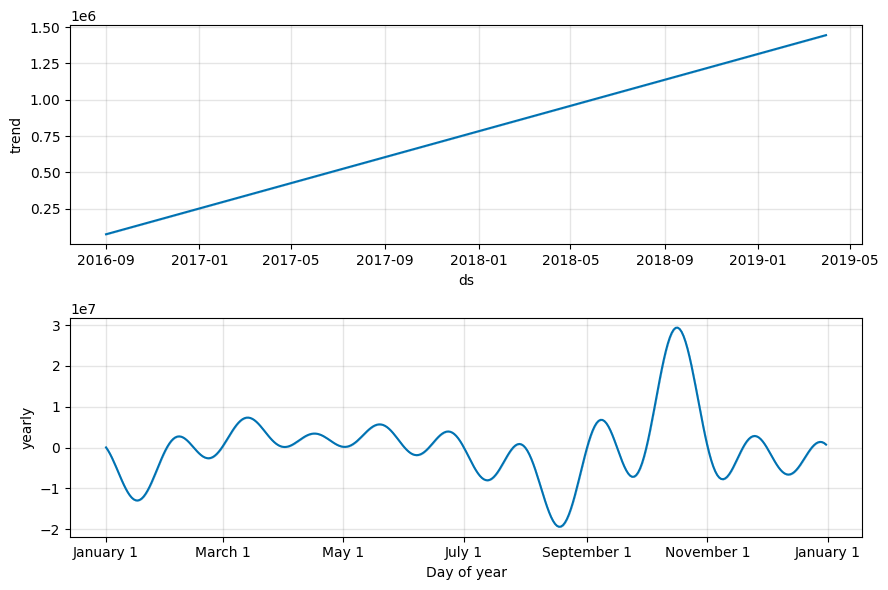

In [53]:
model.plot_components(forecast)
plt.show()